# 01 - Digital Image Basics

This notebook starts the foundation for VisionInspect AI. Before defect detection, we need to understand what a digital image is and how Python sees it.

## Learning Goals

- Understand pixels
- Understand resolution as width x height
- Understand RGB, grayscale, and binary images
- Understand pixel intensity
- Understand common formats: PNG, JPG, BMP, TIFF
- See that images are NumPy arrays

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SAMPLE_DIR = PROJECT_ROOT / "data" / "sample_images"
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\HP\Desktop\springboard\visioninspect-ai


## What Is A Digital Image?

A digital image is a grid of tiny units called pixels. Each pixel stores intensity or color information.

For a color image, each pixel usually has 3 channels:

- Red
- Green
- Blue

An image with shape `(height, width, 3)` is usually an RGB image.

Image shape: (6, 6, 3)
Height: 6
Width: 6
Channels: 3
Pixel at row 0, col 0: [255   0   0]


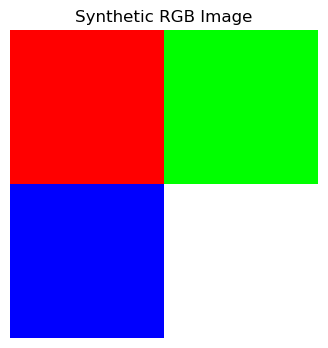

In [2]:
# Create a small synthetic RGB image so we can inspect pixels clearly.
image_rgb = np.zeros((6, 6, 3), dtype=np.uint8)

# Top-left area red
image_rgb[:3, :3] = [255, 0, 0]

# Top-right area green
image_rgb[:3, 3:] = [0, 255, 0]

# Bottom-left area blue
image_rgb[3:, :3] = [0, 0, 255]

# Bottom-right area white
image_rgb[3:, 3:] = [255, 255, 255]

print("Image shape:", image_rgb.shape)
print("Height:", image_rgb.shape[0])
print("Width:", image_rgb.shape[1])
print("Channels:", image_rgb.shape[2])
print("Pixel at row 0, col 0:", image_rgb[0, 0])

plt.figure(figsize=(4, 4))
plt.imshow(image_rgb)
plt.title("Synthetic RGB Image")
plt.axis("off")
plt.show()

## Resolution: Width x Height

Resolution means the size of the image grid.

For example, an image with width 1920 and height 1080 has:

`1920 x 1080 = 2,073,600 pixels`

In NumPy/OpenCV, image shape is usually shown as:

`height, width, channels`

In [3]:
height, width, channels = image_rgb.shape
total_pixels = height * width

print("Width x Height:", f"{width} x {height}")
print("Total pixels:", total_pixels)
print("Channels:", channels)

Width x Height: 6 x 6
Total pixels: 36
Channels: 3


## Grayscale And Binary Images

A grayscale image has one channel. Pixel intensity usually ranges from 0 to 255:

- 0 means black
- 255 means white
- values between them are gray levels

A binary image usually has only two values: 0 and 255.

RGB shape: (6, 6, 3)
Grayscale shape: (6, 6)
Binary unique values: [  0 255]


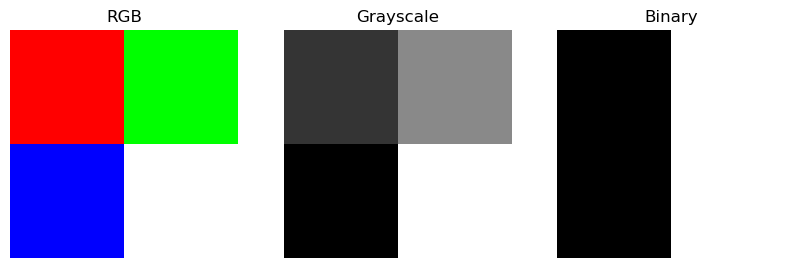

In [4]:
gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

print("RGB shape:", image_rgb.shape)
print("Grayscale shape:", gray.shape)
print("Binary unique values:", np.unique(binary))

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(image_rgb)
axes[0].set_title("RGB")
axes[1].imshow(gray, cmap="gray")
axes[1].set_title("Grayscale")
axes[2].imshow(binary, cmap="gray")
axes[2].set_title("Binary")

for ax in axes:
    ax.axis("off")

plt.show()

## Pixel Intensity

Pixel intensity is the numeric value stored in a pixel.

In most standard 8-bit images:

- Minimum intensity: 0
- Maximum intensity: 255

For RGB images, every pixel has three intensity values: red, green, and blue.

In [5]:
print("RGB min intensity:", image_rgb.min())
print("RGB max intensity:", image_rgb.max())
print("Grayscale min intensity:", gray.min())
print("Grayscale max intensity:", gray.max())

row, col = 0, 0
print(f"RGB pixel at ({row}, {col}):", image_rgb[row, col])
print(f"Grayscale pixel at ({row}, {col}):", gray[row, col])

RGB min intensity: 0
RGB max intensity: 255
Grayscale min intensity: 29
Grayscale max intensity: 255
RGB pixel at (0, 0): [255   0   0]
Grayscale pixel at (0, 0): 76


## Image Formats

Common formats:

- PNG: lossless, good for masks and screenshots
- JPG: compressed, smaller files, can lose detail
- BMP: simple uncompressed format
- TIFF: often used in industrial/scientific imaging

For defect detection datasets, PNG is common because it preserves details and masks cleanly.

In [6]:
# OpenCV saves images in BGR order, so convert RGB to BGR before saving.
image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)

cv2.imwrite(str(SAMPLE_DIR / "synthetic_rgb.png"), image_bgr)
cv2.imwrite(str(SAMPLE_DIR / "synthetic_rgb.jpg"), image_bgr)
cv2.imwrite(str(SAMPLE_DIR / "synthetic_rgb.bmp"), image_bgr)
cv2.imwrite(str(SAMPLE_DIR / "synthetic_rgb.tiff"), image_bgr)

for path in sorted(SAMPLE_DIR.glob("synthetic_rgb.*")):
    print(path.name, "-", path.stat().st_size, "bytes")

synthetic_rgb.bmp - 174 bytes
synthetic_rgb.jpg - 740 bytes
synthetic_rgb.png - 97 bytes
synthetic_rgb.tiff - 208 bytes


## Summary

You now know the base concepts needed for image processing:

- Images are grids of pixels
- Resolution is width x height
- Color images usually have RGB channels
- Grayscale images have one intensity channel
- Binary images contain only two values
- Images are arrays, so NumPy can manipulate them

Next notebook: `02_opencv_numpy_matplotlib.ipynb`.